### Import packages and data

In [319]:
from pathlib import Path
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [320]:
PROJECT_ROOT = Path("/Users/tildeidunsloth/Desktop/Thesis")
SRL_DIR = PROJECT_ROOT / "data" / "SRL"

In [321]:
romance_srl = pd.read_csv(SRL_DIR / "romance_srl_cleaned.csv")
lit_fic_srl = pd.read_csv(SRL_DIR / "literary_fiction_srl_cleaned.csv")
sci_fi_srl = pd.read_csv(SRL_DIR / "sci_fi_srl_cleaned.csv")

In [322]:
# combine
df_all = pd.concat([romance_srl, sci_fi_srl, lit_fic_srl], ignore_index=True)

In [323]:
# rename genres
df_all["genre"] = df_all["genre"].replace({
    "romance": "Romance",
    "Literary_fiction": "Literary Fiction",
    "sci_fi": "Science Fiction"
})

In [324]:
# filter out predicates that aren't verbs
non_verbs = ["collar", "ars", "heavier", "knees", "hand closed", "hand covered"]

df_all = df_all[~df_all["predicate"].isin(non_verbs)]


### Plot frequencies for agent, patient and receiver

In [325]:
gender_cols = ["agent_gender", "patient_gender", "receiver_gender"]

df_long = df_all.melt(
    id_vars="genre",
    value_vars=gender_cols,
    var_name="role",
    value_name="gender"
)

df_long["role"] = df_long["role"].str.replace("_gender", "")
df_long = df_long.dropna(subset=["gender"])

In [326]:
df_counts = (
    df_long
    .groupby(["genre", "role", "gender"])
    .size()
    .reset_index(name="count")
)

df_counts["percentage"] = (
    df_counts
    .groupby(["genre", "role"])["count"]
    .transform(lambda x: 100 * x / x.sum())
)

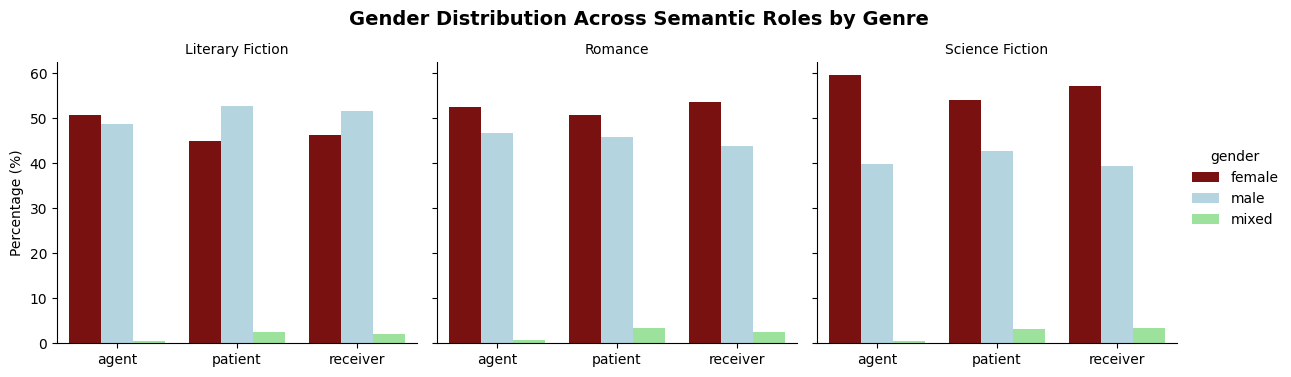

In [327]:
g = sns.catplot(
    data=df_counts,
    x="role",
    y="percentage",
    hue="gender",
    col="genre",
    kind="bar",
    height=4,
    aspect=1,
    palette=["darkred", "lightblue", "lightgreen"]
)

# change titles
g.set_titles("{col_name}", fontsize=12)
g.set_xlabels("")
g.set_ylabels("Percentage (%)")
g.fig.suptitle("Gender Distribution Across Semantic Roles by Genre", fontsize=14, fontweight="bold")
g.fig.subplots_adjust(top=0.85)

plt.show()

### Plot frequencies across agent_type, event_valence and context_valence

### Check which predicates each gender are associated with

In [328]:
gender_cols = ["agent_gender", "patient_gender", "receiver_gender"]
role_cols = ["agent", "patient", "receiver"]

# reshape both role + gender together
df_long_pred = pd.concat([
    df_all.assign(role="agent", entity=df_all["agent"], gender=df_all["agent_gender"]),
    df_all.assign(role="patient", entity=df_all["patient"], gender=df_all["patient_gender"]),
    df_all.assign(role="receiver", entity=df_all["receiver"], gender=df_all["receiver_gender"])
])

# keep only relevant columns
df_long_pred = df_long_pred[["genre", "predicate", "role", "gender"]]

# drop missing
df_long_pred = df_long_pred.dropna(subset=["gender", "predicate"])

In [329]:
min_count = 10 

df_counts_pred = (
    df_long_pred
    .groupby(["genre", "role", "gender", "predicate"])
    .size()
    .reset_index(name="count")
)

df_counts_pred["total_predicate"] = (
    df_counts_pred.groupby(["genre", "role", "predicate"])["count"]
    .transform("sum")
)

df_filtered = df_counts_pred[df_counts_pred["total_predicate"] >= min_count]

# remove gender = mixed
df_filtered = df_filtered[df_filtered["gender"] != "mixed"]

df_filtered["prop"] = (
    df_filtered.groupby(["genre", "role", "predicate"])["count"]
    .transform(lambda x: x / x.sum())
)

In [330]:

# choose top 10 predicates by proportion for each genre, role, and gender
N = 10

df_top = (
    df_filtered
    .sort_values(
        ["genre", "role", "gender", "prop"],
        ascending=[True, True, True, False]
    )
    .groupby(["genre", "role", "gender"])
    .head(N)
)

In [331]:
df_agents = df_top[df_top["role"] == "agent"]
df_patients = df_top[df_top["role"] == "patient"]
df_receivers = df_top[df_top["role"] == "receiver"] 

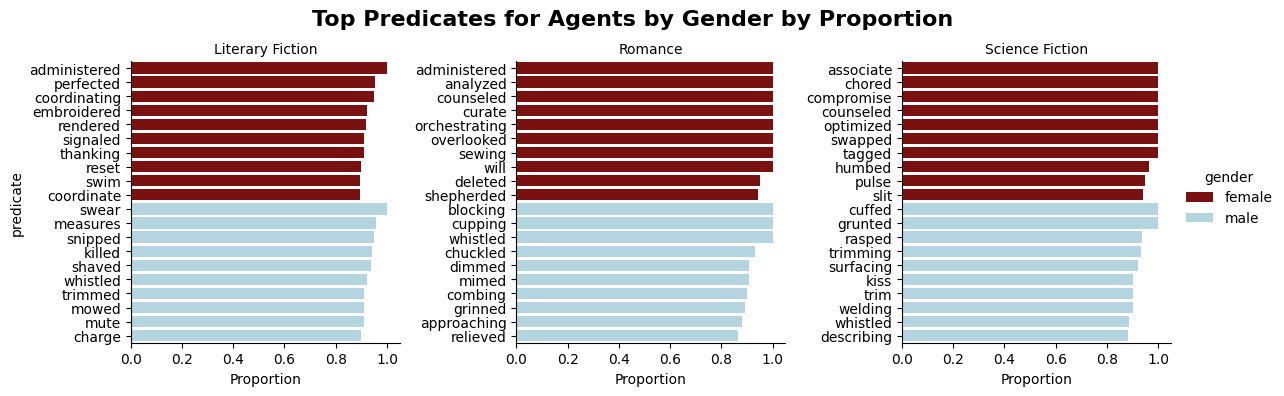

In [347]:

g = sns.catplot(
    data=df_agents,
    y="predicate",
    x="prop",
    hue="gender",
    col="genre",
    kind="bar",
    sharey=False,
    sharex=False,
    height=4,
    aspect=1,
    palette=["darkred", "lightblue"]
)

g.set_titles("{col_name}")
g.set_xlabels("Proportion")
g.set_ylabels(None)

g.fig.suptitle("Top Predicates for Agents by Gender by Proportion", fontsize=16, fontweight = "bold")
g.fig.subplots_adjust(top=0.85)

plt.show()

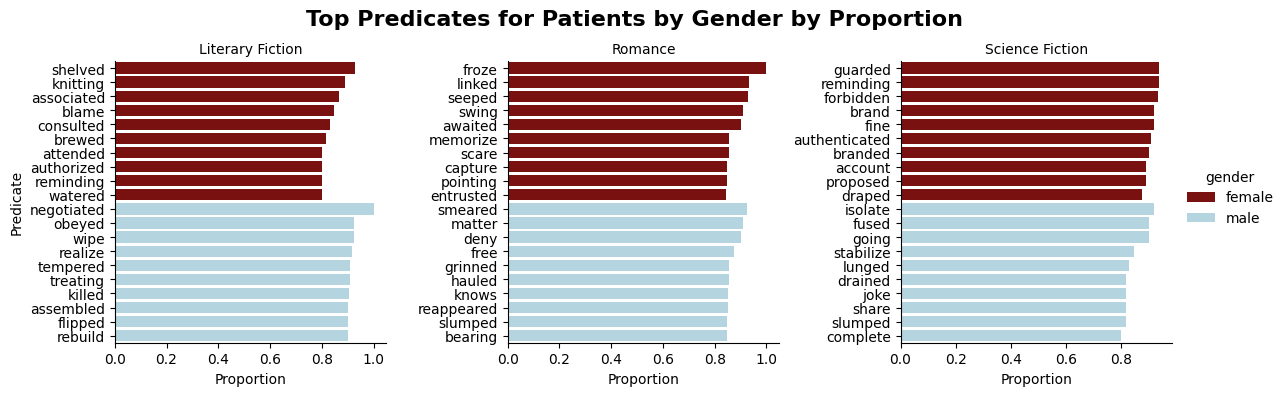

In [344]:
g = sns.catplot(
    data=df_patients,
    y="predicate",
    x="prop",
    hue="gender",
    col="genre",
    kind="bar",
    sharey=False,
    sharex=False,
    height=4,
    aspect=1,
    palette=["darkred", "lightblue"]
)

g.set_titles("{col_name}")
g.set_xlabels("Proportion")
g.set_ylabels("Predicate")

g.fig.suptitle("Top Predicates for Patients by Gender by Proportion", fontsize=16, fontweight = "bold")
g.fig.subplots_adjust(top=0.85)

plt.show()

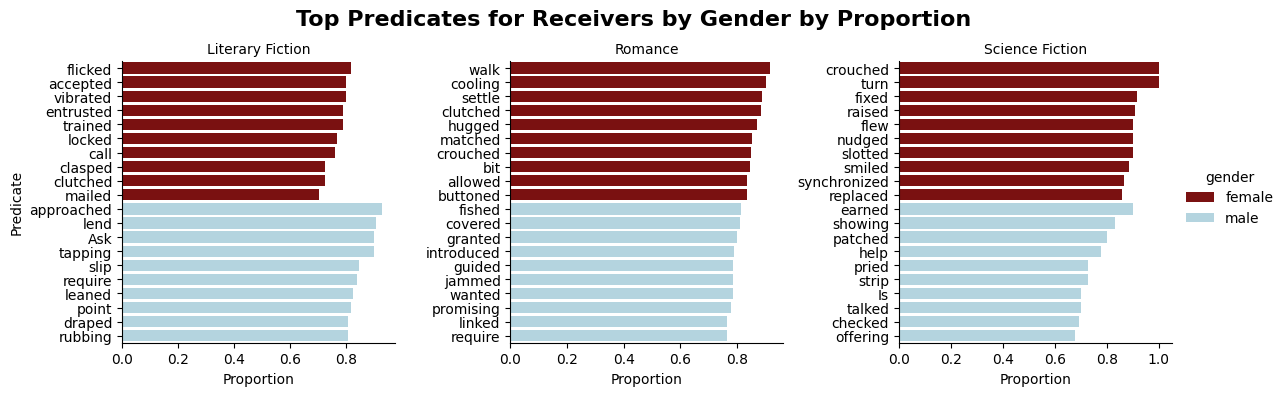

In [348]:
g = sns.catplot(
    data=df_receivers,
    y="predicate",
    x="prop",
    hue="gender",
    col="genre",
    kind="bar",
    sharey=False,
    sharex=False,
    height=4,
    aspect=1,
    palette=["darkred", "lightblue"]
)

g.set_titles("{col_name}")
g.set_xlabels("Proportion")
g.set_ylabels("Predicate")

g.fig.suptitle("Top Predicates for Receivers by Gender by Proportion", fontsize=16, fontweight = "bold")
g.fig.subplots_adjust(top=0.85)

plt.show()